In [ ]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Give the path of your CSV file
file_path = "/content/drive/MyDrive/Student.csv.xlsx - Student.csv"

print("File path:")
print(file_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
File path:
/content/drive/MyDrive/Student.csv.xlsx - Student.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import norm, ttest_1samp

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import math
import random
import statistics
import os

print("All libraries imported successfully.")

All libraries imported successfully.


In [ ]:
try:

    df = pd.read_csv(file_path)

    print("=" * 60)
    print("DATASET LOADED SUCCESSFULLY")
    print("=" * 60)

    print("Number of Students :", len(df))
    print("Number of Columns  :", len(df.columns))

    print("\nDataset:")
    display(df)

except FileNotFoundError:

    print("ERROR: File not found.")
    print("Please check the file path:")
    print(file_path)

except Exception as e:

    print("ERROR:", e)

DATASET LOADED SUCCESSFULLY
Number of Students : 20
Number of Columns  : 12

Dataset:


,Roll No,Name,Branch,Semester,Birth Date,Email,Mobile Number,Maths,Python,Data Science,Statistics,Computer
0,1,Jeel Moradiya,CE,5,8/8/2006,jeel.m@example.com,9825250062,95,85,82,80,92
1,2,Aarav Patel,CE,5,2/14/2005,aarav.patel@example.com,9000000002,82,88,85,79,91
2,3,Vivaan Shah,IT,5,5/21/2005,vivaan.shah@example.com,9000000003,74,81,78,72,84
3,4,Aditya Mehta,CE,5,11/8/2004,aditya.mehta@example.com,9000000004,91,94,89,92,95
4,5,Rohan Desai,IT,5,7/17/2005,rohan.desai@example.com,9000000005,63,69,66,61,72
5,6,Dhruv Joshi,CE,5,1/29/2005,dhruv.joshi@example.com,9000000006,45,52,48,43,55
6,7,Krish Trivedi,IT,5,9/12/2004,krish.trivedi@example.com,9000000007,77,73,80,75,78
7,8,Yash Patel,CE,5,3/26/2005,yash.patel@example.com,9000000008,56,62,59,54,65
8,9,Harsh Shah,IT,5,12/3/2004,harsh.shah@example.com,9000000009,88,84,91,86,89
9,10,Dev Mehta,CE,5,6/19/2005,dev.mehta@example.com,9000000010,39,46,42,38,49


In [ ]:
print("========== DATASET INFORMATION ==========")

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nDataset Shape:")
print(df.shape)

print("\nFirst 5 Records:")
display(df.head())

========== DATASET INFORMATION ==========

Column Names:
['Roll No', 'Name', 'Branch', 'Semester', 'Birth Date', 'Email', 'Mobile Number', 'Maths', 'Python', 'Data Science', 'Statistics', 'Computer']

Data Types:
Roll No           int64
Name             object
Branch           object
Semester          int64
Birth Date       object
Email            object
Mobile Number     int64
Maths             int64
Python            int64
Data Science      int64
Statistics        int64
Computer          int64
dtype: object

Dataset Shape:
(20, 12)

First 5 Records:


,Roll No,Name,Branch,Semester,Birth Date,Email,Mobile Number,Maths,Python,Data Science,Statistics,Computer
0,1,Jeel Moradiya,CE,5,8/8/2006,jeel.m@example.com,9825250062,95,85,82,80,92
1,2,Aarav Patel,CE,5,2/14/2005,aarav.patel@example.com,9000000002,82,88,85,79,91
2,3,Vivaan Shah,IT,5,5/21/2005,vivaan.shah@example.com,9000000003,74,81,78,72,84
3,4,Aditya Mehta,CE,5,11/8/2004,aditya.mehta@example.com,9000000004,91,94,89,92,95
4,5,Rohan Desai,IT,5,7/17/2005,rohan.desai@example.com,9000000005,63,69,66,61,72


In [ ]:
project_name = "Student Performance Analytics"

subjects = ["Maths", "Python", "Data_Science", "Statistics", "Computer"]

marks_list = [80, 85, 90, 75, 88]

branches = {"CE", "IT"}

student_info = {
    "Project": project_name,
    "Semester": 5
}

print("Project:", project_name)
print("Subjects:", subjects)
print("Marks:", marks_list)
print("Branches:", branches)
print("Student Info:", student_info)

Project: Student Performance Analytics
Subjects: ['Maths', 'Python', 'Data_Science', 'Statistics', 'Computer']
Marks: [80, 85, 90, 75, 88]
Branches: {'IT', 'CE'}
Student Info: {'Project': 'Student Performance Analytics', 'Semester': 5}


In [ ]:
# Convert marks into numeric values

# Correcting the subjects list to match the DataFrame's column names
# The column 'Data_Science' should be 'Data Science' (with a space)
subjects = ["Maths", "Python", "Data Science", "Statistics", "Computer"]

for subject in subjects:
    df[subject] = pd.to_numeric(df[subject], errors="coerce")

# Check for non-numeric values
# After applying pd.to_numeric with errors='coerce', non-numeric values become NaN
# So, we can directly check for NaNs in the subject columns.
non_numeric_values = df[subjects].isna().sum()
print("\nNon-Numeric Values:")
print(non_numeric_values)


# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Check missing marks
print("\nMissing Marks:")
print(df[subjects].isnull().sum())

# Fill missing marks with median
for subject in subjects:
    df[subject] = df[subject].fillna(df[subject].median())

# Remove duplicate records
df = df.drop_duplicates()

# Clean Branch column
df["Branch"] = df["Branch"].astype(str).str.strip().str.upper()

print("\nCleaned Dataset:")
display(df.head())


Non-Numeric Values:
Maths           0
Python          0
Data Science    0
Statistics      0
Computer        0
dtype: int64

Missing Values:
Roll No          0
Name             0
Branch           0
Semester         0
Birth Date       0
Email            0
Mobile Number    0
Maths            0
Python           0
Data Science     0
Statistics       0
Computer         0
dtype: int64

Missing Marks:
Maths           0
Python          0
Data Science    0
Statistics      0
Computer        0
dtype: int64

Cleaned Dataset:


,Roll No,Name,Branch,Semester,Birth Date,Email,Mobile Number,Maths,Python,Data Science,Statistics,Computer
0,1,Jeel Moradiya,CE,5,8/8/2006,jeel.m@example.com,9825250062,95,85,82,80,92
1,2,Aarav Patel,CE,5,2/14/2005,aarav.patel@example.com,9000000002,82,88,85,79,91
2,3,Vivaan Shah,IT,5,5/21/2005,vivaan.shah@example.com,9000000003,74,81,78,72,84
3,4,Aditya Mehta,CE,5,11/8/2004,aditya.mehta@example.com,9000000004,91,94,89,92,95
4,5,Rohan Desai,IT,5,7/17/2005,rohan.desai@example.com,9000000005,63,69,66,61,72


In [ ]:
df["Total"] = df[subjects].sum(axis=1)

df["Percentage"] = df["Total"] / len(subjects)

def calculate_grade(percentage):
    if percentage >= 90:
        return "A+"
    elif percentage >= 80:
        return "A"
    elif percentage >= 70:
        return "B"
    elif percentage >= 60:
        return "C"
    elif percentage >= 50:
        return "D"
    elif percentage >= 40:
        return "E"
    else:
        return "F"

def calculate_result(percentage):
    return "PASS" if percentage >= 40 else "FAIL"

df["Grade"] = df["Percentage"].apply(calculate_grade)
df["Result"] = df["Percentage"].apply(calculate_result)

display(df[["Roll No", "Name", "Total", "Percentage", "Grade", "Result"]])

,Roll No,Name,Total,Percentage,Grade,Result
0,1,Jeel Moradiya,434,86.8,A,PASS
1,2,Aarav Patel,425,85.0,A,PASS
2,3,Vivaan Shah,389,77.8,B,PASS
3,4,Aditya Mehta,461,92.2,A+,PASS
4,5,Rohan Desai,331,66.2,C,PASS
5,6,Dhruv Joshi,243,48.6,E,PASS
6,7,Krish Trivedi,383,76.6,B,PASS
7,8,Yash Patel,296,59.2,D,PASS
8,9,Harsh Shah,438,87.6,A,PASS
9,10,Dev Mehta,214,42.8,E,PASS


In [ ]:
marks = df[subjects].to_numpy()

print("Average Marks:", np.mean(marks))
print("Highest Mark:", np.max(marks))
print("Lowest Mark:", np.min(marks))

print("\nStatistics:")
print("Mean Percentage:", df["Percentage"].mean())
print("Median Percentage:", df["Percentage"].median())
print("Standard Deviation:", df["Percentage"].std())

# SciPy
mode_result = stats.mode(df["Percentage"], keepdims=True)

print("Mode Percentage:", mode_result.mode[0])

Average Marks: 72.13
Highest Mark: 96
Lowest Mark: 38

Statistics:
Mean Percentage: 72.13000000000001
Median Percentage: 76.19999999999999
Standard Deviation: 16.54967323576288
Mode Percentage: 42.8


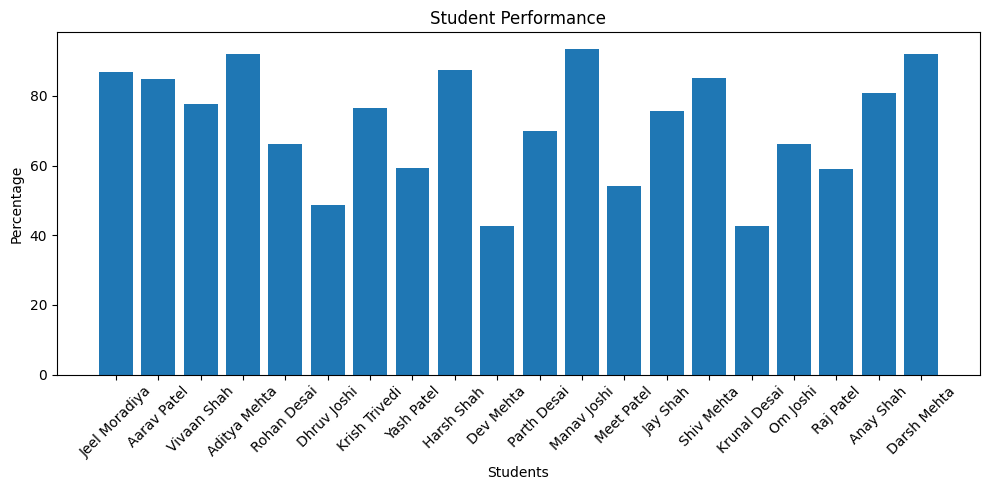

In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(df["Name"], df["Percentage"])

plt.xlabel("Students")
plt.ylabel("Percentage")
plt.title("Student Performance")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

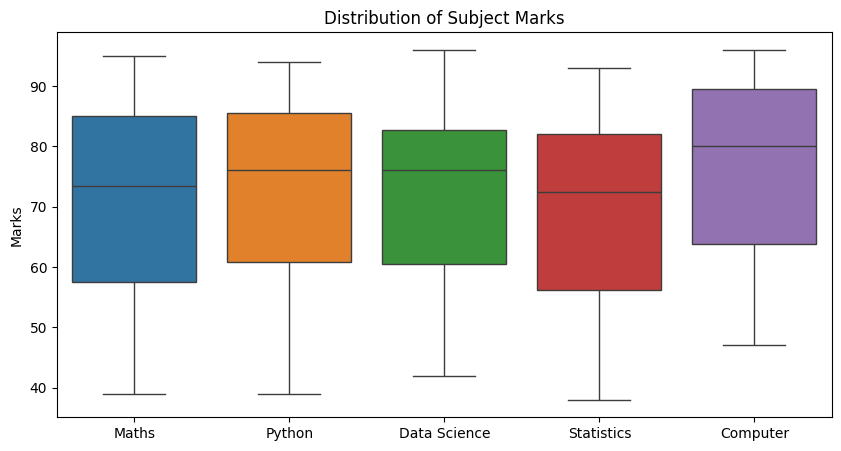

In [ ]:
plt.figure(figsize=(10, 5))

sns.boxplot(data=df[subjects])

plt.title("Distribution of Subject Marks")
plt.ylabel("Marks")

plt.show()

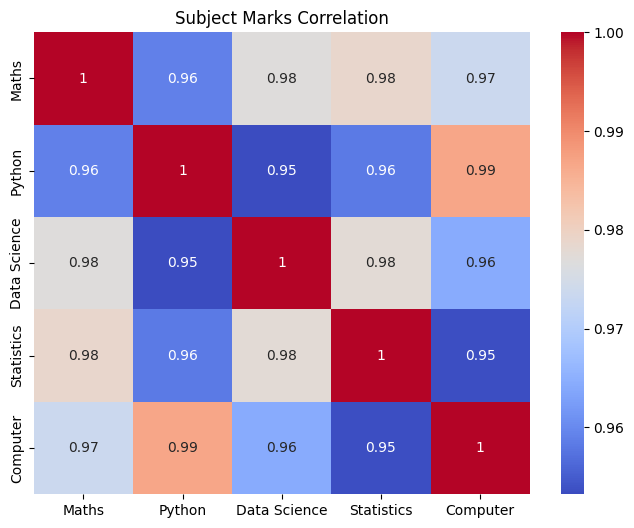

In [ ]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    df[subjects].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Subject Marks Correlation")

plt.show()

In [ ]:
X = df[subjects]
y = df["Result"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Random Forest Accuracy:", round(accuracy * 100, 2), "%")

Random Forest Accuracy: 100.0 %


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


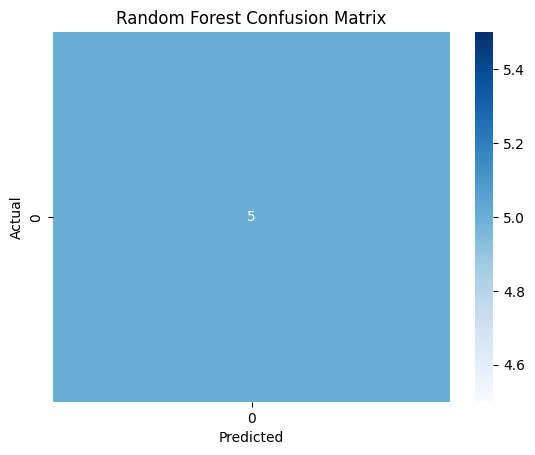

In [ ]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [ ]:
# CODE 13: NEW STUDENT DETAILS AND PREDICTION

print("========== NEW STUDENT DETAILS ==========")

roll_no = input("Enter Roll No: ")
name = input("Enter Student Name: ")
mobile = input("Enter Mobile Number: ")
birth_date = input("Enter Birth Date (DD-MM-YYYY): ")
email = input("Enter Email: ")

print("\nEnter Subject Marks")

new_marks = []

for subject in subjects:
    mark = float(input("Enter " + subject + " marks: "))
    new_marks.append(mark)

# Prepare data for Random Forest
new_student = np.array(new_marks).reshape(1, -1)

# Predict Pass/Fail
prediction = model.predict(new_student)[0]

# Calculate performance
total = sum(new_marks)
percentage = total / len(subjects)
grade = calculate_grade(percentage)

print("\n========== STUDENT DETAILS ==========")
print("Roll No:", roll_no)
print("Name:", name)
print("Mobile:", mobile)
print("Birth Date:", birth_date)
print("Email:", email)

print("\n========== PERFORMANCE ==========")
print("Total Marks:", total)
print("Percentage:", round(percentage, 2))
print("Grade:", grade)
print("Predicted Result:", prediction)

========== NEW STUDENT DETAILS ==========
Enter Roll No: 21
Enter Student Name: Krutik
Enter Mobile Number: 9863125478
Enter Birth Date (DD-MM-YYYY): 05-05-2006
Enter Email: kru08@example.com

Enter Subject Marks
Enter Maths marks: 95
Enter Python marks: 96
Enter Data Science marks: 85
Enter Statistics marks: 80
Enter Computer marks: 85

========== STUDENT DETAILS ==========
Roll No: 21
Name: Krutik
Mobile: 9863125478
Birth Date: 05-05-2006
Email: kru08@example.com

========== PERFORMANCE ==========
Total Marks: 441.0
Percentage: 88.2
Grade: A
Predicted Result: PASS


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
cluster_data = df[subjects]

scaler = StandardScaler()

scaled_data = scaler.fit_transform(cluster_data)

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(scaled_data)

print("Student Clusters:")
display(df[["Name", "Percentage", "Cluster"]])

cluster_average = df.groupby("Cluster")["Percentage"].mean()

print("Average Percentage of Each Cluster:")
print(cluster_average)

sorted_clusters = cluster_average.sort_values().index

cluster_names = {
    sorted_clusters[0]: "Low Performance",
    sorted_clusters[1]: "Average Performance",
    sorted_clusters[2]: "High Performance"
}

df["Performance_Group"] = df["Cluster"].map(cluster_names)

display(
    df[["Name", "Percentage", "Cluster", "Performance_Group"]]
)

Student Clusters:


,Name,Percentage,Cluster
0,Jeel Moradiya,86.8,0
1,Aarav Patel,85.0,0
2,Vivaan Shah,77.8,2
3,Aditya Mehta,92.2,0
4,Rohan Desai,66.2,2
5,Dhruv Joshi,48.6,1
6,Krish Trivedi,76.6,2
7,Yash Patel,59.2,1
8,Harsh Shah,87.6,0
9,Dev Mehta,42.8,1


Average Percentage of Each Cluster:
Cluster
0    88.914286
1    51.100000
2    73.371429
Name: Percentage, dtype: float64


,Name,Percentage,Cluster,Performance_Group
0,Jeel Moradiya,86.8,0,High Performance
1,Aarav Patel,85.0,0,High Performance
2,Vivaan Shah,77.8,2,Average Performance
3,Aditya Mehta,92.2,0,High Performance
4,Rohan Desai,66.2,2,Average Performance
5,Dhruv Joshi,48.6,1,Low Performance
6,Krish Trivedi,76.6,2,Average Performance
7,Yash Patel,59.2,1,Low Performance
8,Harsh Shah,87.6,0,High Performance
9,Dev Mehta,42.8,1,Low Performance


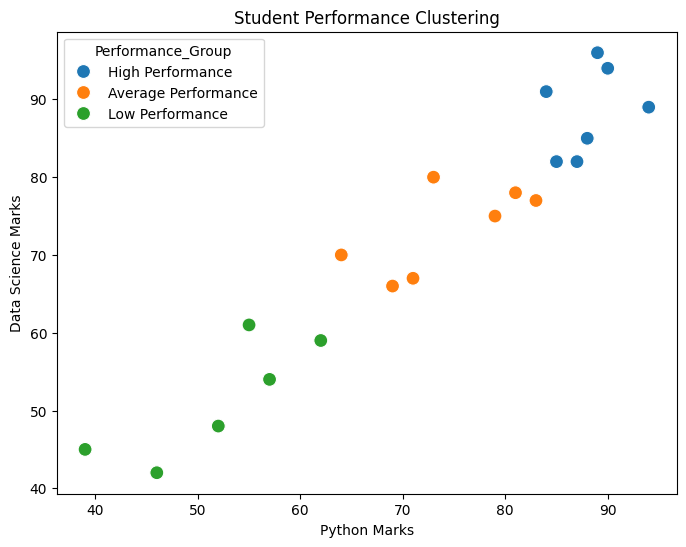

In [ ]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="Python",
    y="Data Science",
    hue="Performance_Group",
    s=100
)

plt.title("Student Performance Clustering")
plt.xlabel("Python Marks")
plt.ylabel("Data Science Marks")

plt.show()

In [ ]:
print("========== FINAL RESULTS ==========")

print("Total Students:", len(df))
print("Average Percentage:", round(df["Percentage"].mean(), 2))
print("Highest Percentage:", round(df["Percentage"].max(), 2))
print("Lowest Percentage:", round(df["Percentage"].min(), 2))

print("\nPASS:", len(df[df["Result"] == "PASS"]))
print("FAIL:", len(df[df["Result"] == "FAIL"]))

print("\nPerformance Groups:")
print(df["Performance_Group"].value_counts())

print("\nMachine Learning Model: Random Forest")
print("Beyond-Syllabus Topic: K-Means Clustering")

========== FINAL RESULTS ==========
Total Students: 20
Average Percentage: 72.13
Highest Percentage: 93.6
Lowest Percentage: 42.8

PASS: 20
FAIL: 0

Performance Groups:
Performance_Group
High Performance       7
Average Performance    7
Low Performance        6
Name: count, dtype: int64

Machine Learning Model: Random Forest
Beyond-Syllabus Topic: K-Means Clustering


In [ ]:
import os

output_path = "/content/drive/MyDrive/PBL/final_student_analysis.csv"

# Extract the directory path
output_directory = os.path.dirname(output_path)

# Create the directory if it does not exist
os.makedirs(output_directory, exist_ok=True)

df.to_csv(output_path, index=False)

print("Final dataset saved successfully!")
print(output_path)

Final dataset saved successfully!
/content/drive/MyDrive/PBL/final_student_analysis.csv
